# Unidad 3: Búsqueda, Optimización y Agentes Inteligentes
## 🗺️ Búsqueda No Informada (Ciega)
### Inteligencia Artificial — Lic. en Sistemas — FCAD/UNER

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/CristianPacifico/ia-ls-fcad-uner/blob/main/notebooks/search/01_BusquedaNoInformada.ipynb)

## 🎯 Objetivos de Aprendizaje

Al finalizar este notebook vas a poder:

✅ Comprender qué es un **espacio de estados** y cómo se navega  
✅ Implementar y comparar los algoritmos de búsqueda ciega: **BFS**, **DFS**, **UCS** e **IDS**  
✅ Analizar las propiedades de cada algoritmo: **completitud**, **optimalidad** y **complejidad**  
✅ Usar la librería `simpleai` para formular y resolver problemas de búsqueda  
✅ Visualizar el espacio de búsqueda como un grafo con `networkx` y `matplotlib`

---

## 📖 Marco Teórico

### ¿Qué es la búsqueda en IA?

Muchos problemas de IA pueden formularse como la búsqueda de un **camino en un espacio de estados**:

- **Estado inicial**: situación de partida
- **Estado meta**: situación deseada
- **Acciones**: transiciones posibles entre estados
- **Costo**: peso de cada transición

```
Estado Inicial ──acción──▶ Estado 1 ──acción──▶ ... ──acción──▶ Estado Meta
```

### Búsquedas No Informadas

No utilizan información sobre el dominio del problema. Solo conocen la **estructura del grafo**.

| Algoritmo | Estrategia | Completo | Óptimo | Memoria |
|-----------|-----------|----------|--------|---------|
| **BFS** (Anchura) | Explora nivel por nivel | ✅ Sí | ✅ Sí (costo uniforme) | Alta ⚠️ |
| **DFS** (Profundidad) | Baja hasta el fondo primero | ⚠️ Sí (grafo finito) | ❌ No | Baja ✅ |
| **UCS** (Costo Uniforme) | Expande el nodo de menor costo | ✅ Sí | ✅ Sí | Media |
| **IDS** (Profund. Iterativa) | DFS con límite creciente | ✅ Sí | ✅ Sí (costo uniforme) | Baja ✅ |

### El Problema: Mapa de Rumanía

Usamos el ejemplo clásico del libro **Artificial Intelligence: A Modern Approach** (Russell & Norvig).  
El agente debe viajar desde **Arad** hasta **Bucarest** por carretera.

```
Arad ─── Zerind ─── Oradea ─── Sibiu ─── ...
 │                              │
Timisoara                    Rimnicu
 │                              │
Lugoj ─── Mehadia ─── ...   Pitesti ─── Bucarest
```

> 📌 **Objetivo**: Encontrar el camino de menor costo desde Arad hasta Bucarest.


## 📖 Librerías en python

### 1. `aima-python` — La más completa para IA académica
Implementación oficial del libro *Artificial Intelligence: A Modern Approach* (Russell & Norvig). Incluye todos los algoritmos del mapa anterior: BFS, DFS, UCS, IDS, A\*, Greedy, hill climbing, simulated annealing y más.

```bash
# bash
pip install aima3
```

```python
# python
from search import Problem, astar_search, breadth_first_search

class MiProblema(Problem):
    def actions(self, state): ...
    def result(self, state, action): ...
    def goal_test(self, state): ...
    def h(self, node): ...  # heurística para A*

problema = MiProblema(initial=..., goal=...)
solucion = astar_search(problema)
```

---

### 2. `networkx` — Para búsquedas en grafos
No es específica de IA, pero tiene BFS, DFS, Dijkstra (≈ UCS) y A\* listos para grafos.

```python
# python
import networkx as nx

G = nx.Graph()
G.add_weighted_edges_from([("A","B",1), ("B","C",4), ("A","C",2)])

# A* con heurística propia
path = nx.astar_path(G, "A", "C", heuristic=lambda u,v: 0)

# Dijkstra (costo uniforme)
path = nx.dijkstra_path(G, "A", "C")
```

---

### 3. `pyperplan` — Para planificación con PDDL
Orientada a problemas de planificación formal. Incluye BFS, DFS, A\* y búsqueda por haz (*beam search*).

---

### 4. `simpleai` — La más didáctica
Diseñada específicamente para aprender IA. API muy limpia, basada también en el libro de Russell & Norvig.

```bash
# bash
pip install simpleai
```

```python
# python
from simpleai.search import astar, breadth_first, depth_first
from simpleai.search import SearchProblem

class MiProblema(SearchProblem):
    def actions(self, state): ...
    def result(self, state, action): ...
    def is_goal(self, state): ...
    def heuristic(self, state): ...

result = astar(MiProblema(initial_state=...))
```

---

### Resumen rápido

| Librería | BFS | DFS | UCS | A\* | Local | Ideal para |
|---|---|---|---|---|---|---|
| `aima3` | ✓ | ✓ | ✓ | ✓ | ✓ | Estudio académico |
| `networkx` | ✓ | ✓ | ✓ | ✓ | — | Grafos reales |
| `simpleai` | ✓ | ✓ | ✓ | ✓ | ✓ | Aprendizaje / prototipos |
| `pyperplan` | ✓ | ✓ | — | ✓ | — | Planificación PDDL |

En este curso usaremos **`simpleai`** por estar mejor documentada y ser más simple implementando los algoritmos de [AIMA]. En algunos casos se utilizará **`networkx`** para trabajar con grafos.

## 📦 Paso 1: Instalación e Imports

In [2]:
# Instalar librerías necesarias (solo si no están disponibles)
!pip install simpleai networkx --quiet

In [3]:
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

import matplotlib.pyplot as plt
import networkx as nx

from simpleai.search import (
    SearchProblem,
    breadth_first,
    depth_first,
    uniform_cost,
    iterative_limited_depth_first,
)

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


## 🗺️ Paso 2: Definición del Mapa de Rumanía

Definimos el mapa como un diccionario donde cada ciudad tiene una lista de vecinos con sus distancias reales por carretera (en km). Estos datos provienen de la figura 3.2 del libro de Russell & Norvig.

In [4]:
# Mapa de Rumanía: {ciudad: [(vecino, distancia_km), ...]}
ROMANIA_MAP = {
    'Arad':           [('Zerind', 75),   ('Sibiu', 140),    ('Timisoara', 118)],
    'Zerind':         [('Arad', 75),     ('Oradea', 71)],
    'Oradea':         [('Zerind', 71),   ('Sibiu', 151)],
    'Sibiu':          [('Arad', 140),    ('Oradea', 151),   ('Fagaras', 99),   ('Rimnicu', 80)],
    'Timisoara':      [('Arad', 118),    ('Lugoj', 111)],
    'Lugoj':          [('Timisoara', 111), ('Mehadia', 70)],
    'Mehadia':        [('Lugoj', 70),    ('Drobeta', 75)],
    'Drobeta':        [('Mehadia', 75),  ('Craiova', 120)],
    'Craiova':        [('Drobeta', 120), ('Rimnicu', 146),  ('Pitesti', 138)],
    'Rimnicu':        [('Sibiu', 80),    ('Craiova', 146),  ('Pitesti', 97)],
    'Fagaras':        [('Sibiu', 99),    ('Bucarest', 211)],
    'Pitesti':        [('Rimnicu', 97),  ('Craiova', 138),  ('Bucarest', 101)],
    'Bucarest':       [('Fagaras', 211), ('Pitesti', 101),  ('Giurgiu', 90),   ('Urziceni', 85)],
    'Giurgiu':        [('Bucarest', 90)],
    'Urziceni':       [('Bucarest', 85), ('Vaslui', 142),   ('Hirsova', 98)],
    'Hirsova':        [('Urziceni', 98), ('Eforie', 86)],
    'Eforie':         [('Hirsova', 86)],
    'Vaslui':         [('Urziceni', 142), ('Iasi', 92)],
    'Iasi':           [('Vaslui', 92),   ('Neamt', 87)],
    'Neamt':          [('Iasi', 87)],
}

INITIAL_STATE = 'Arad'
GOAL_STATE = 'Bucarest'

print(f"📍 Estado inicial: {INITIAL_STATE}")
print(f"🏁 Estado meta:    {GOAL_STATE}")
print(f"🗺️ Ciudades en el mapa: {len(ROMANIA_MAP)}")

📍 Estado inicial: Arad
🏁 Estado meta:    Bucarest
🗺️ Ciudades en el mapa: 20


## 📊 Paso 3: Visualización del Grafo

Construimos el grafo con `networkx` y lo graficamos con `matplotlib`. Los nodos de inicio y meta se destacan con colores especiales.

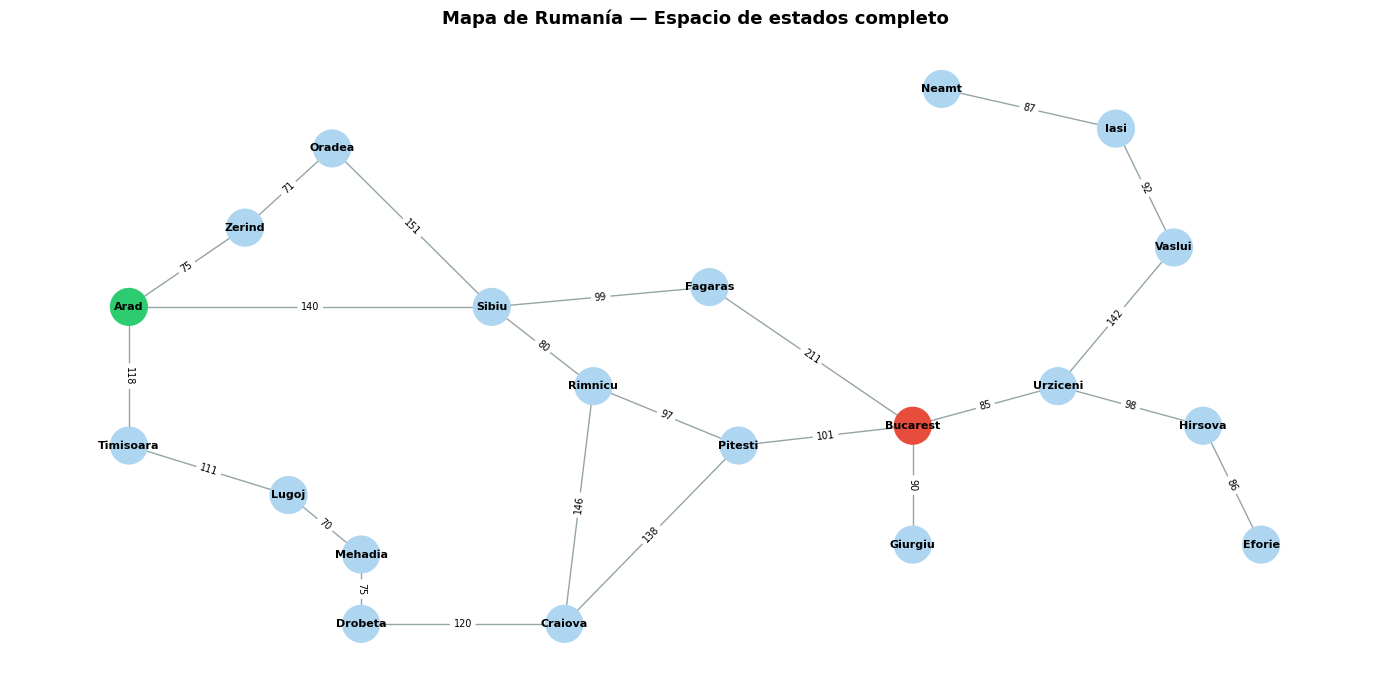

In [13]:
def build_graph(map_data):
    """Construye un grafo NetworkX a partir del diccionario del mapa."""
    G = nx.Graph()
    for city, neighbors in map_data.items():
        for neighbor, dist in neighbors:
            G.add_edge(city, neighbor, weight=dist)
    return G


def draw_romania(G, path=None, title='Mapa de Rumanía', ax=None):
    """Dibuja el grafo de Rumanía, opcionalmente resaltando un camino."""
    # Layout aproximado geográfico
    pos = {
        'Arad':       (0.0, 3.2),  'Zerind':    (0.8, 4.0),
        'Oradea':     (1.4, 4.8),  'Sibiu':     (2.5, 3.2),
        'Timisoara':  (0.0, 1.8),  'Lugoj':     (1.1, 1.3),
        'Mehadia':    (1.6, 0.7),  'Drobeta':   (1.6, 0.0),
        'Craiova':    (3.0, 0.0),  'Rimnicu':   (3.2, 2.4),
        'Fagaras':    (4.0, 3.4),  'Pitesti':   (4.2, 1.8),
        'Bucarest':   (5.4, 2.0),  'Giurgiu':   (5.4, 0.8),
        'Urziceni':   (6.4, 2.4),  'Hirsova':   (7.4, 2.0),
        'Eforie':     (7.8, 0.8),  'Vaslui':    (7.2, 3.8),
        'Iasi':       (6.8, 5.0),  'Neamt':     (5.6, 5.4),
    }

    node_colors = []
    for node in G.nodes():
        if node == INITIAL_STATE:
            node_colors.append('#2ecc71')   # verde: inicio
        elif node == GOAL_STATE:
            node_colors.append('#e74c3c')   # rojo: meta
        elif path and node in path:
            node_colors.append('#f39c12')   # naranja: en el camino
        else:
            node_colors.append('#aed6f1')   # azul claro: otros

    edge_colors = []
    edge_widths = []
    path_edges = set()
    if path:
        path_edges = {(path[i], path[i+1]) for i in range(len(path)-1)}
        path_edges |= {(b, a) for a, b in path_edges}

    for u, v in G.edges():
        if (u, v) in path_edges:
            edge_colors.append('#e67e22')
            edge_widths.append(3.5)
        else:
            edge_colors.append('#95a5a6')
            edge_widths.append(1.0)

    if ax is None:
        fig, ax = plt.subplots(figsize=(14, 7))

    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=700, ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=8, font_weight='bold', ax=ax)
    nx.draw_networkx_edges(G, pos, edge_color=edge_colors, width=edge_widths, ax=ax)
    edge_labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7, ax=ax)

    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.axis('off')


G = build_graph(ROMANIA_MAP)
draw_romania(G, title='Mapa de Rumanía — Espacio de estados completo')
plt.tight_layout()
plt.show()

## 🧩 Paso 4: Formulación del Problema con `simpleai`

La librería `simpleai` requiere que definamos nuestro problema como una clase que hereda de `SearchProblem` e implementa tres métodos obligatorios:

| Método | Descripción |
|--------|-------------|
| `actions(state)` | Devuelve las acciones posibles desde un estado |
| `result(state, action)` | Aplica una acción y devuelve el nuevo estado |
| `is_goal(state)` | Retorna `True` si el estado es la meta |
| `cost(state, action, result)` | (Opcional) Retorna el costo de una acción |

> 💡 El estado en este problema es simplemente el **nombre de la ciudad** actual.

In [5]:
class RomaniaProblem(SearchProblem):
    """Problema de búsqueda: navegar el mapa de Rumanía desde Arad hasta Bucarest."""

    def actions(self, state):
        """Retorna las ciudades vecinas accesibles desde el estado actual."""
        return [neighbor for neighbor, _ in ROMANIA_MAP.get(state, [])]

    def result(self, state, action):
        """El resultado de ir a 'action' es estar en 'action'."""
        return action

    def is_goal(self, state):
        """La meta es llegar a Bucarest."""
        return state == GOAL_STATE

    def cost(self, state, action, result):
        """El costo es la distancia en km entre la ciudad actual y la vecina."""
        for neighbor, dist in ROMANIA_MAP.get(state, []):
            if neighbor == action:
                return dist
        return float('inf')


def get_path_and_cost(result):
    """Extrae el camino y el costo total de un resultado de simpleai."""
    if result is None:
        return None, None
    path = [state for _, state in result.path()]
    cost = result.cost
    return path, cost


print("✅ Clase RomaniaProblem definida")
problem = RomaniaProblem(initial_state=INITIAL_STATE)
print(f"   Acciones desde Arad: {problem.actions('Arad')}")

✅ Clase RomaniaProblem definida
   Acciones desde Arad: ['Zerind', 'Sibiu', 'Timisoara']


## 🔍 Paso 5: BFS — Búsqueda en Anchura

**BFS** (*Breadth-First Search*) explora el grafo nivel por nivel, garantizando encontrar el camino con **menor cantidad de pasos**.

- ✅ **Completo**: siempre encuentra solución si existe
- ✅ **Óptimo**: en grafos con costos uniformes
- ⚠️ **Memoria**: almacena todos los nodos del nivel actual (exponencial)

```
Nivel 0:  Arad
Nivel 1:  Zerind, Sibiu, Timisoara
Nivel 2:  Oradea, Fagaras, Rimnicu, Lugoj, ...
...
```

In [6]:
problem = RomaniaProblem(initial_state=INITIAL_STATE)
result_bfs = breadth_first(problem, graph_search=True)
path_bfs, cost_bfs = get_path_and_cost(result_bfs)

print("🔍 BFS — Búsqueda en Anchura")
print(f"   Camino: {' → '.join(path_bfs)}")
print(f"   Costo total: {cost_bfs} km")
print(f"   Pasos: {len(path_bfs) - 1}")

🔍 BFS — Búsqueda en Anchura
   Camino: Arad → Sibiu → Fagaras → Bucarest
   Costo total: 450 km
   Pasos: 3


## 🔍 Paso 6: DFS — Búsqueda en Profundidad

**DFS** (*Depth-First Search*) baja por una rama hasta el fondo antes de retroceder.

- ⚠️ **Completo**: solo si el grafo es finito y se usa `graph_search=True` (evita ciclos)
- ❌ **No óptimo**: puede encontrar una solución muy larga
- ✅ **Memoria**: solo guarda el camino actual (lineal)

> 📌 La solución de DFS puede ser muy diferente (y más costosa) que la de BFS.

In [7]:
problem = RomaniaProblem(initial_state=INITIAL_STATE)
result_dfs = depth_first(problem, graph_search=True)
path_dfs, cost_dfs = get_path_and_cost(result_dfs)

print("🔍 DFS — Búsqueda en Profundidad")
print(f"   Camino: {' → '.join(path_dfs)}")
print(f"   Costo total: {cost_dfs} km")
print(f"   Pasos: {len(path_dfs) - 1}")

🔍 DFS — Búsqueda en Profundidad
   Camino: Arad → Timisoara → Lugoj → Mehadia → Drobeta → Craiova → Pitesti → Bucarest
   Costo total: 733 km
   Pasos: 7


## 🔍 Paso 7: UCS — Búsqueda de Costo Uniforme

**UCS** (*Uniform Cost Search*) expande siempre el nodo con **menor costo acumulado** desde el inicio, usando una cola de prioridad.

- ✅ **Completo**: sí
- ✅ **Óptimo**: sí — garantiza el camino de menor costo total
- 📌 Es la generalización de BFS para grafos con costos distintos en cada arista

> 💡 UCS es equivalente al algoritmo de **Dijkstra** de la teoría de grafos.

In [8]:
problem = RomaniaProblem(initial_state=INITIAL_STATE)
result_ucs = uniform_cost(problem, graph_search=True)
path_ucs, cost_ucs = get_path_and_cost(result_ucs)

print("🔍 UCS — Búsqueda de Costo Uniforme")
print(f"   Camino: {' → '.join(path_ucs)}")
print(f"   Costo total: {cost_ucs} km  ← camino óptimo")
print(f"   Pasos: {len(path_ucs) - 1}")

🔍 UCS — Búsqueda de Costo Uniforme
   Camino: Arad → Sibiu → Rimnicu → Pitesti → Bucarest
   Costo total: 418 km  ← camino óptimo
   Pasos: 4


## 🔍 Paso 8: IDS — Profundización Iterativa

**IDS** (*Iterative Deepening Search*) ejecuta DFS repetidamente con un límite de profundidad creciente (1, 2, 3, ...) hasta encontrar la solución.

- ✅ **Completo**: sí
- ✅ **Óptimo**: sí (en grafos con costos uniformes)
- ✅ **Memoria**: igual que DFS (solo el camino actual)

```
Iteración con límite=1:  Arad, Zerind, Sibiu, Timisoara  → no encuentra meta
Iteración con límite=2:  niveles 0,1,2                   → no encuentra meta
...
Iteración con límite=k:  ¡encuentra Bucarest!
```

> 📌 IDS es la estrategia preferida cuando **no hay heurística** disponible y la memoria es limitada.

In [9]:
problem = RomaniaProblem(initial_state=INITIAL_STATE)
result_ids = iterative_limited_depth_first(problem, graph_search=True)
path_ids, cost_ids = get_path_and_cost(result_ids)

print("🔍 IDS — Profundización Iterativa")
print(f"   Camino: {' → '.join(path_ids)}")
print(f"   Costo total: {cost_ids} km")
print(f"   Pasos: {len(path_ids) - 1}")

🔍 IDS — Profundización Iterativa
   Camino: Arad → Sibiu → Fagaras → Bucarest
   Costo total: 450 km
   Pasos: 3


## 📊 Paso 9: Comparativa de Algoritmos

Comparamos los cuatro algoritmos ejecutados sobre el mismo problema:

In [10]:
import pandas as pd

resultados = [
    ('BFS',  path_bfs,  cost_bfs,  '✅ Sí', '✅ Solo costo uniforme', '⚠️ Alta'),
    ('DFS',  path_dfs,  cost_dfs,  '✅ Sí', '❌ No',                   '✅ Baja'),
    ('UCS',  path_ucs,  cost_ucs,  '✅ Sí', '✅ Sí',                   '⚠️ Media'),
    ('IDS',  path_ids,  cost_ids,  '✅ Sí', '✅ Solo costo uniforme', '✅ Baja'),
]

df = pd.DataFrame(resultados, columns=['Algoritmo', 'Camino', 'Costo (km)', 'Completo', 'Óptimo', 'Memoria'])
df['Pasos'] = df['Camino'].apply(lambda p: len(p) - 1 if p else None)
df['Camino'] = df['Camino'].apply(lambda p: ' → '.join(p) if p else 'Sin solución')

print("\n📊 Comparativa de algoritmos de búsqueda no informada\n")
print(df[['Algoritmo', 'Costo (km)', 'Pasos', 'Completo', 'Óptimo', 'Memoria']].to_string(index=False))
print("\n📋 Caminos encontrados:")
for _, row in df.iterrows():
    print(f"   {row['Algoritmo']:4s}: {row['Camino']}")


📊 Comparativa de algoritmos de búsqueda no informada

Algoritmo  Costo (km)  Pasos Completo                Óptimo  Memoria
      BFS         450      3     ✅ Sí ✅ Solo costo uniforme  ⚠️ Alta
      DFS         733      7     ✅ Sí                  ❌ No   ✅ Baja
      UCS         418      4     ✅ Sí                  ✅ Sí ⚠️ Media
      IDS         450      3     ✅ Sí ✅ Solo costo uniforme   ✅ Baja

📋 Caminos encontrados:
   BFS : Arad → Sibiu → Fagaras → Bucarest
   DFS : Arad → Timisoara → Lugoj → Mehadia → Drobeta → Craiova → Pitesti → Bucarest
   UCS : Arad → Sibiu → Rimnicu → Pitesti → Bucarest
   IDS : Arad → Sibiu → Fagaras → Bucarest


## 🗺️ Paso 10: Visualización de Caminos

Graficamos los cuatro caminos encontrados sobre el mapa de Rumanía. Los nodos del camino se destacan en **naranja**, el inicio en **verde** y la meta en **rojo**.

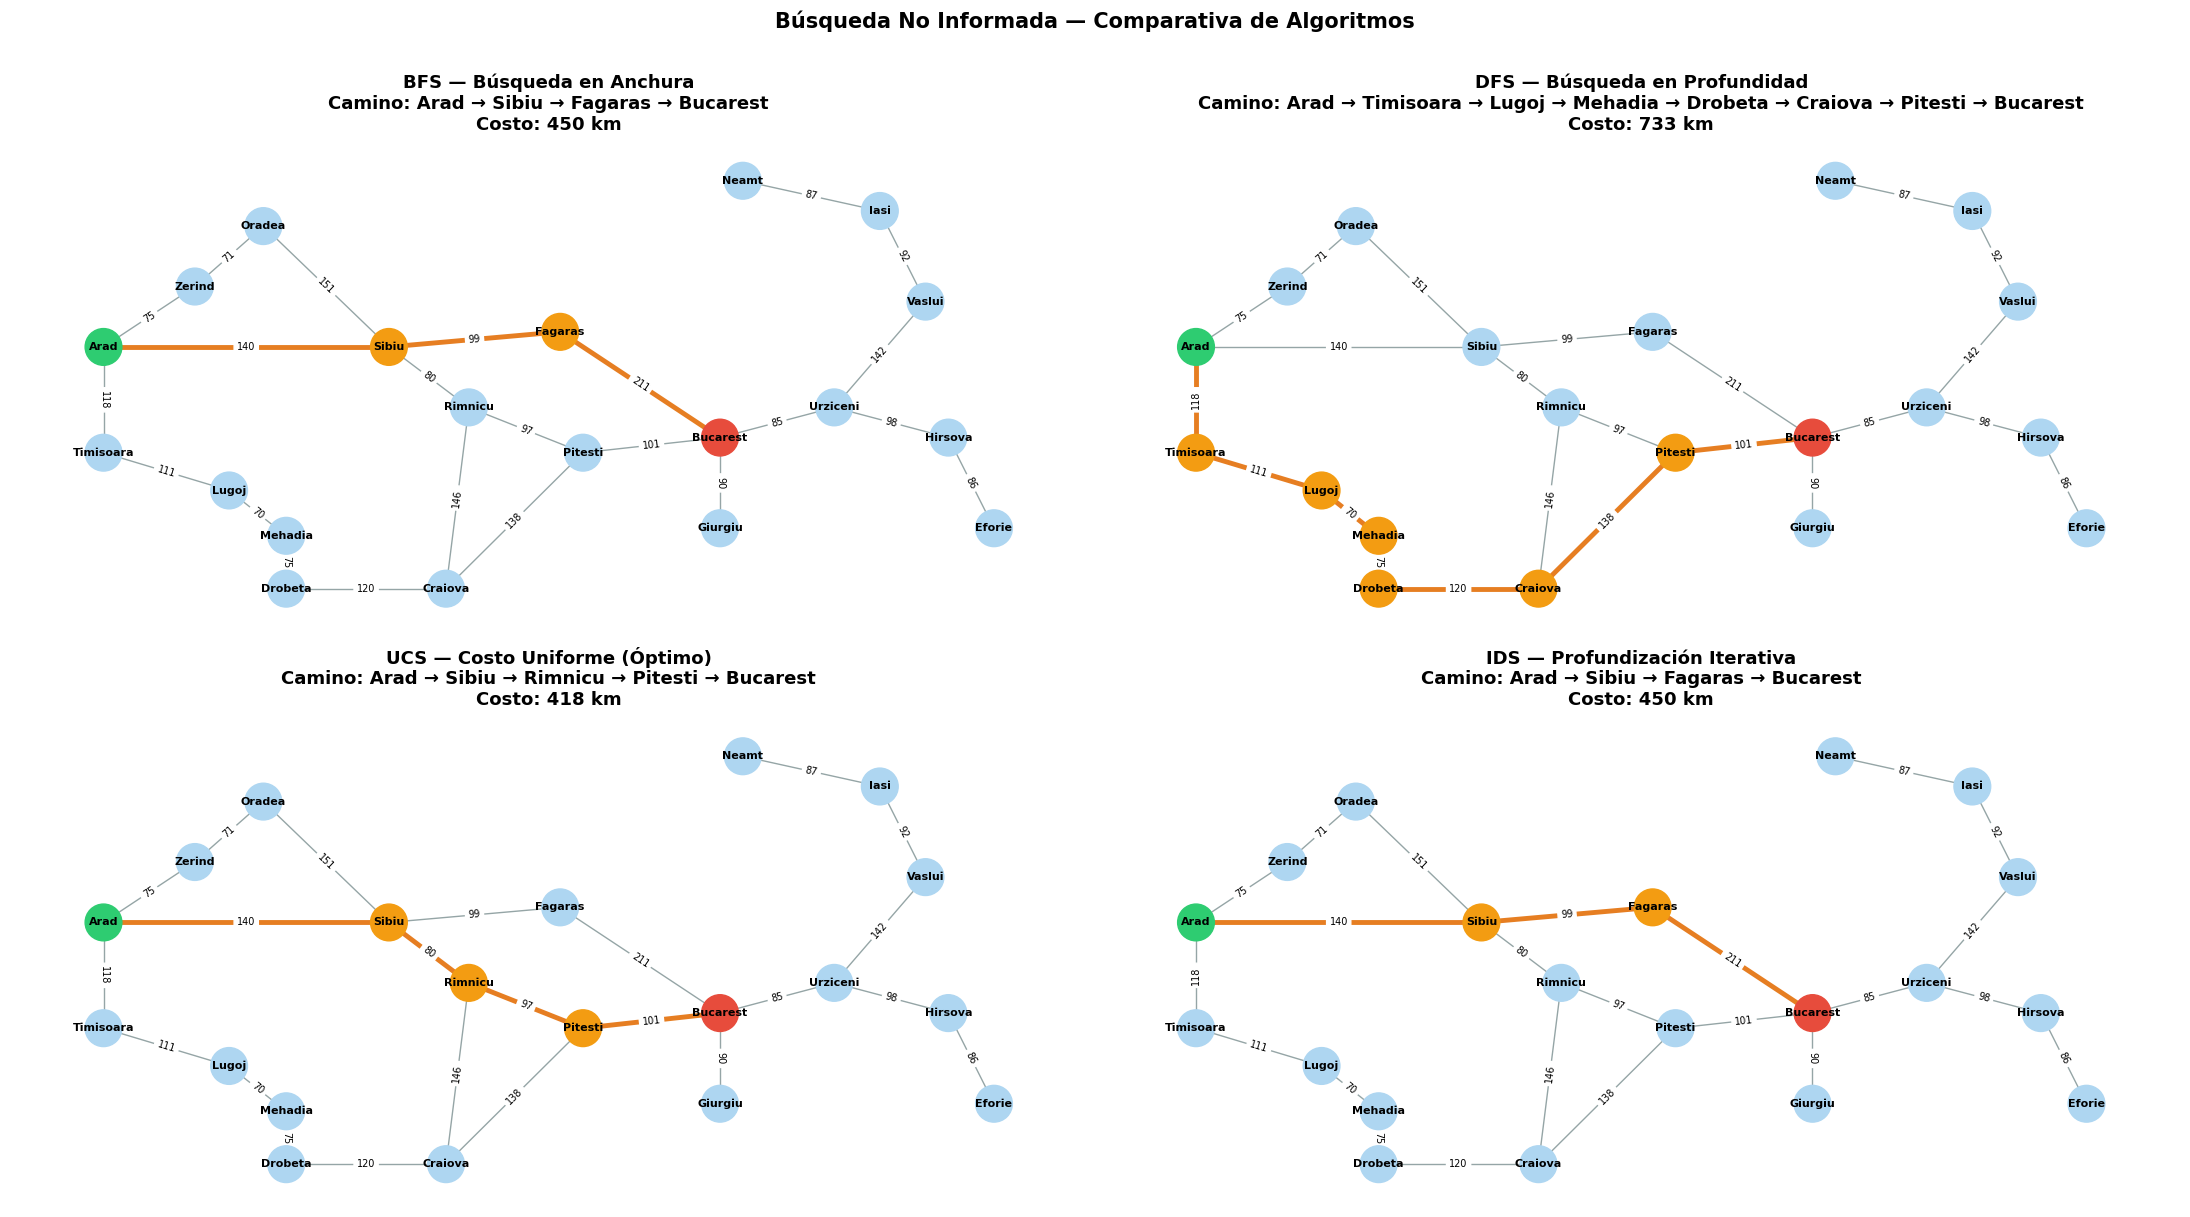

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(22, 12))
axes = axes.flatten()

configs = [
    (path_bfs, cost_bfs, 'BFS — Búsqueda en Anchura'),
    (path_dfs, cost_dfs, 'DFS — Búsqueda en Profundidad'),
    (path_ucs, cost_ucs, 'UCS — Costo Uniforme (Óptimo)'),
    (path_ids, cost_ids, 'IDS — Profundización Iterativa'),
]

for ax, (path, cost, title) in zip(axes, configs):
    draw_romania(G, path=path, title=f'{title}\nCamino: {" → ".join(path)}\nCosto: {cost} km', ax=ax)

plt.suptitle('Búsqueda No Informada — Comparativa de Algoritmos', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 🎓 Resumen y Conclusiones

En este notebook aprendimos:

1. 🗺️ **El espacio de estados**: cómo formular un problema de IA como la búsqueda de un camino en un grafo
2. 🔍 **BFS**: explora nivel por nivel, óptimo solo con costos uniformes, alta demanda de memoria
3. 🔍 **DFS**: profundidad primero, eficiente en memoria, pero no garantiza optimalidad
4. 🔍 **UCS**: expande por costo acumulado, siempre óptimo, equivalente al algoritmo de Dijkstra
5. 🔍 **IDS**: combina DFS con límite de profundidad creciente, óptimo y eficiente en memoria
6. 📊 **Comparativa visual**: los cuatro algoritmos sobre el Mapa de Rumanía usando `networkx` y `matplotlib`

### Puntos clave

- **UCS es la única estrategia ciega óptima** cuando los costos de las aristas son variables
- **BFS e IDS** son óptimos solo si todos los costos son iguales (grafos sin peso)
- **DFS** puede recorrer caminos muy costosos, pero usa poca memoria
- El camino óptimo Arad → Bucarest es de **418 km**: Arad → Sibiu → Rimnicu → Pitesti → Bucarest
- `simpleai` requiere definir `actions`, `result`, `is_goal` y opcionalmente `cost`

### 🚀 ¿Qué sigue?

- 🧭 **Búsqueda Informada (Greedy, A\*)**: agregar una heurística para guiar la búsqueda y reducir los nodos explorados → [02 — Búsqueda Informada](02_BusquedaInformada.ipynb)
- ♟️ **Búsqueda Adversaria (Minimax, Alpha-Beta)**: cuando hay un oponente que también toma decisiones
- 🎲 **Búsqueda Local**: Hill Climbing, Simulated Annealing, Algoritmos Genéticos — optimizar sin importar el camino

> 📚 **Referencias:**
> - Russell, S. & Norvig, P. (2020). *Artificial Intelligence: A Modern Approach* (4th ed.). Pearson.
> - [simpleai — documentación oficial](https://simpleai.readthedocs.io/)
> - [NetworkX — Graph Drawing](https://networkx.org/documentation/stable/reference/drawing.html)

---

© 2026 Cátedra Inteligencia Artificial — Lic. en Sistemas

Este notebook se distribuye bajo licencia [CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/).